In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")

data

,time,latitude,longitude,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,2023-11-15,20.00,87.00,0.281021,-0.006259,-0.022032,0.053912,0.001012,1.868117,0.000773,1.615477,213.70070,8.144088,25.942343,29.705456,28.077726,9.377943e-08
1,2023-11-15,20.00,87.25,0.307757,-0.239613,-0.096364,0.056723,0.000788,0.651579,0.002323,1.524284,213.01610,8.151818,25.696281,29.530020,28.035090,1.243761e-06
2,2023-11-15,20.00,87.50,0.361767,-0.274904,-0.155237,0.061546,0.000665,0.060814,0.013914,1.535927,209.88200,8.116321,30.314780,32.050990,28.162968,4.969929e-06
3,2023-11-15,20.00,87.75,0.269444,-0.050030,0.156805,0.052620,0.000643,0.023415,0.045637,1.560925,207.31833,8.058519,32.787670,36.222424,28.436258,-7.740124e-07
4,2023-11-15,20.00,88.00,0.260333,-0.017039,0.178411,0.052023,0.000686,0.022156,0.056481,1.668919,206.24165,8.051982,32.575330,36.790690,28.268316,-6.153559e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95584,2025-11-24,21.75,91.00,6.086784,0.019307,-0.006726,0.354040,0.006740,67.023110,0.007953,51.056564,292.53955,8.476734,4.108316,14.158175,26.029886,-2.036619e-07
95585,2025-11-24,22.00,90.50,4.213870,0.036492,0.022951,0.264383,0.008627,24.784285,0.006856,13.655972,297.13720,8.379571,7.059252,11.646044,26.047014,5.422925e-07
95586,2025-11-24,22.00,90.75,5.841083,0.052426,-0.003523,0.332640,0.008557,42.097630,0.007924,25.359040,315.37875,8.417076,6.135298,12.288780,26.050995,-2.651847e-07
95587,2025-11-24,22.25,91.00,6.891112,0.013623,-0.001812,0.371102,0.009915,80.340970,0.117012,34.292390,394.87420,8.521251,0.835270,14.133733,26.278051,-1.312876e-08


In [3]:
# Create a version WITHOUT time/lat/lon ONLY for plotting & EDA
data_no_coords = data.drop(['time', 'latitude', 'longitude'], axis=1)

data_no_coords

,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,0.281021,-0.006259,-0.022032,0.053912,0.001012,1.868117,0.000773,1.615477,213.70070,8.144088,25.942343,29.705456,28.077726,9.377943e-08
1,0.307757,-0.239613,-0.096364,0.056723,0.000788,0.651579,0.002323,1.524284,213.01610,8.151818,25.696281,29.530020,28.035090,1.243761e-06
2,0.361767,-0.274904,-0.155237,0.061546,0.000665,0.060814,0.013914,1.535927,209.88200,8.116321,30.314780,32.050990,28.162968,4.969929e-06
3,0.269444,-0.050030,0.156805,0.052620,0.000643,0.023415,0.045637,1.560925,207.31833,8.058519,32.787670,36.222424,28.436258,-7.740124e-07
4,0.260333,-0.017039,0.178411,0.052023,0.000686,0.022156,0.056481,1.668919,206.24165,8.051982,32.575330,36.790690,28.268316,-6.153559e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95584,6.086784,0.019307,-0.006726,0.354040,0.006740,67.023110,0.007953,51.056564,292.53955,8.476734,4.108316,14.158175,26.029886,-2.036619e-07
95585,4.213870,0.036492,0.022951,0.264383,0.008627,24.784285,0.006856,13.655972,297.13720,8.379571,7.059252,11.646044,26.047014,5.422925e-07
95586,5.841083,0.052426,-0.003523,0.332640,0.008557,42.097630,0.007924,25.359040,315.37875,8.417076,6.135298,12.288780,26.050995,-2.651847e-07
95587,6.891112,0.013623,-0.001812,0.371102,0.009915,80.340970,0.117012,34.292390,394.87420,8.521251,0.835270,14.133733,26.278051,-1.312876e-08


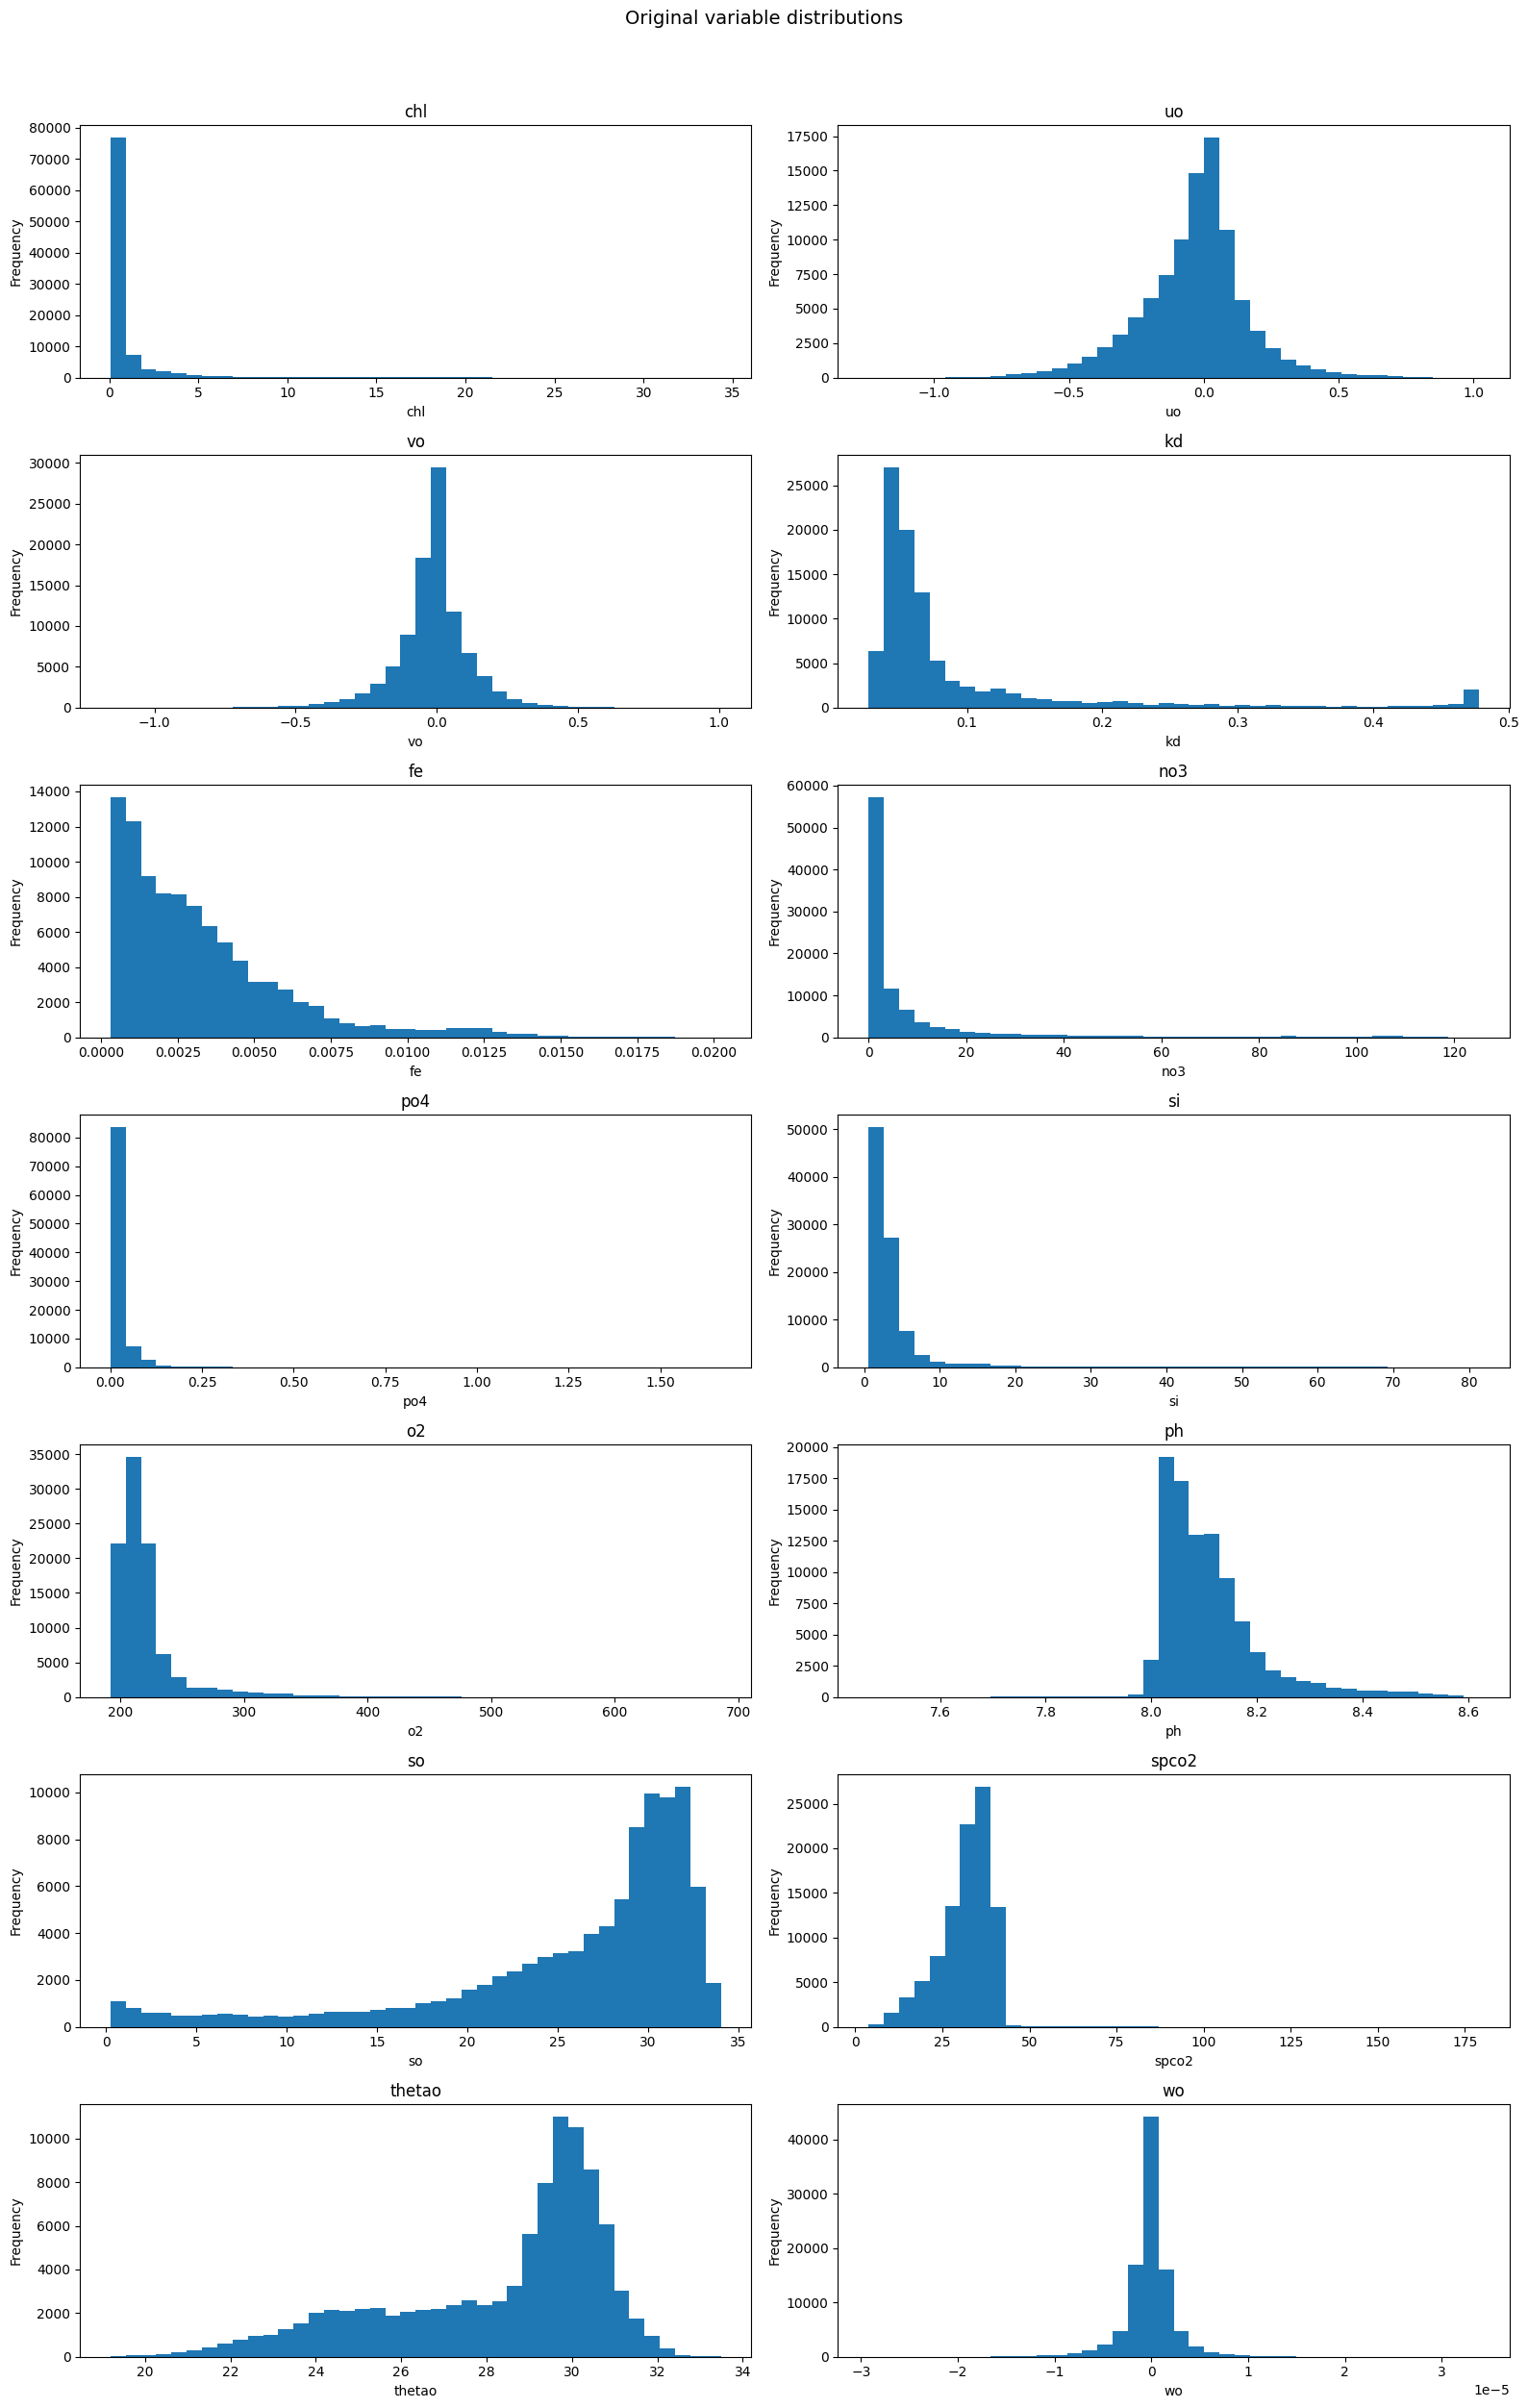

In [4]:
n = data_no_coords.shape[1]
cols_per_row = 2
rows = (n + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(16, rows * 3.5))
for i, col in enumerate(data_no_coords.columns):
    ax = plt.subplot(rows, cols_per_row, i + 1)
    # coerce to numeric for plotting safety
    vals = pd.to_numeric(data_no_coords[col], errors="coerce").dropna()
    if vals.size == 0:
        ax.text(0.5, 0.5, f"No numeric data\nfor {col}", ha="center", va="center")
        ax.set_title(col)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ax.hist(vals, bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Original variable distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

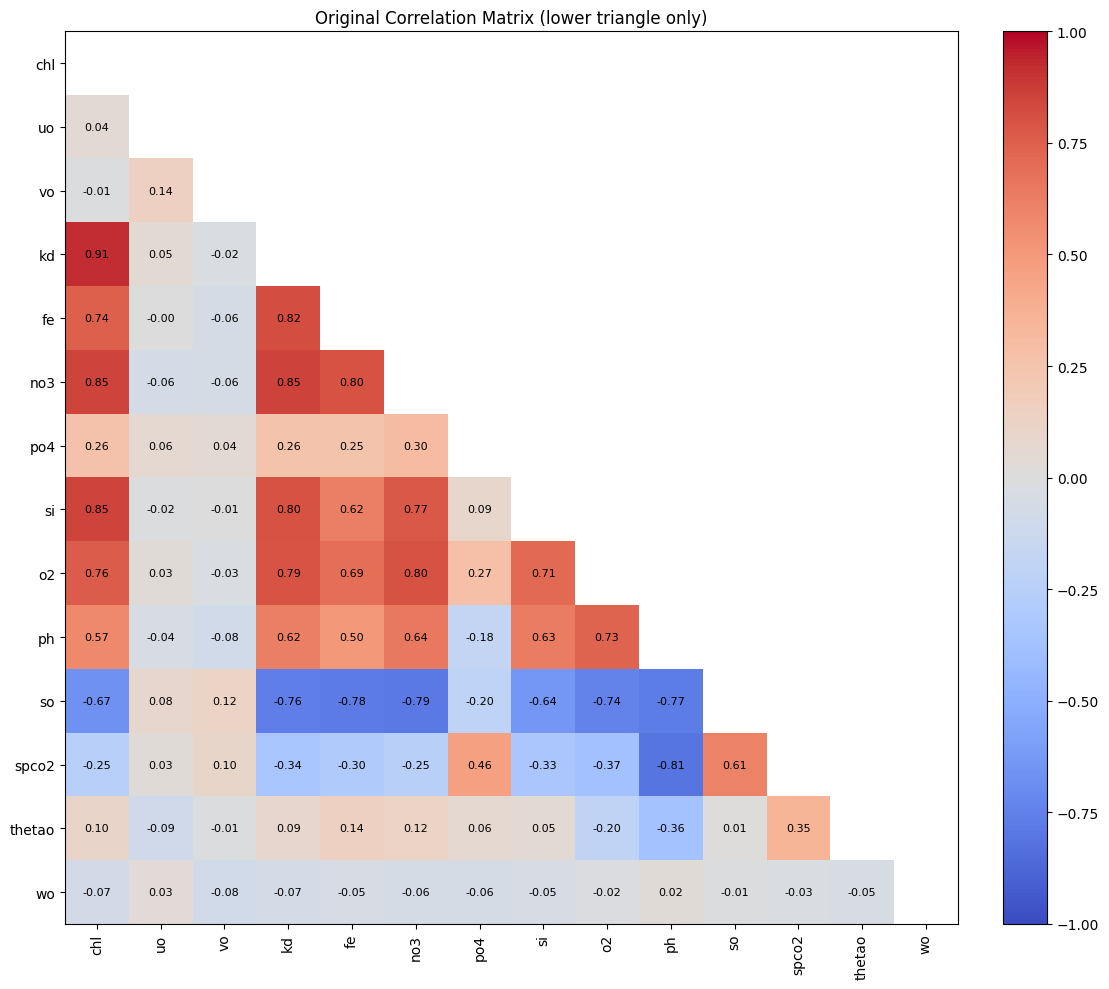

In [5]:
corr = data_no_coords.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

fig, ax = plt.subplots(figsize=(12, 10))
# Masked values are drawn as white
im = ax.imshow(corr.where(~mask), cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Show correlation coefficients in the lower triangle only
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i > j:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.title("Original Correlation Matrix (lower triangle only)")
plt.tight_layout()
plt.show()

In [6]:
# Apply np.log1p (safe log) transform to the selected columns
log1p_cols = ["kd", "fe", "no3", "po4", "si", "o2", "spco2"]

# Create a copy of the data to preserve the original
data_log1p = data.copy()

for col in log1p_cols:
    # Only apply transformation if the column exists (extra safety)
    if col in data_log1p.columns:
        data_log1p[col] = np.log1p(pd.to_numeric(data_log1p[col], errors="coerce"))

data_log1p

,time,latitude,longitude,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,2023-11-15,20.00,87.00,0.281021,-0.006259,-0.022032,0.052509,0.001012,1.053656,0.000772,0.961447,5.369245,8.144088,25.942343,3.424440,28.077726,9.377943e-08
1,2023-11-15,20.00,87.25,0.307757,-0.239613,-0.096364,0.055173,0.000787,0.501732,0.002320,0.925958,5.366051,8.151818,25.696281,3.418710,28.035090,1.243761e-06
2,2023-11-15,20.00,87.50,0.361767,-0.274904,-0.155237,0.059727,0.000665,0.059037,0.013818,0.930559,5.351299,8.116321,30.314780,3.498052,28.162968,4.969929e-06
3,2023-11-15,20.00,87.75,0.269444,-0.050030,0.156805,0.051282,0.000643,0.023145,0.044626,0.940369,5.339067,8.058519,32.787670,3.616911,28.436258,-7.740124e-07
4,2023-11-15,20.00,88.00,0.260333,-0.017039,0.178411,0.050715,0.000686,0.021914,0.054943,0.981674,5.333886,8.051982,32.575330,3.632063,28.268316,-6.153559e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95584,2025-11-24,21.75,91.00,6.086784,0.019307,-0.006726,0.303093,0.006718,4.219848,0.007922,3.952331,5.682012,8.476734,4.108316,2.718540,26.029886,-2.036619e-07
95585,2025-11-24,22.00,90.50,4.213870,0.036492,0.022951,0.234584,0.008590,3.249765,0.006832,2.684848,5.697554,8.379571,7.059252,2.537344,26.047014,5.422925e-07
95586,2025-11-24,22.00,90.75,5.841083,0.052426,-0.003523,0.287162,0.008521,3.763468,0.007893,3.271811,5.756940,8.417076,6.135298,2.586920,26.050995,-2.651847e-07
95587,2025-11-24,22.25,91.00,6.891112,0.013623,-0.001812,0.315615,0.009866,4.398650,0.110657,3.563667,5.981096,8.521251,0.835270,2.716926,26.278051,-1.312876e-08


In [7]:
# Create a version WITHOUT time/lat/lon ONLY for plotting & EDA
data_log1p_no_coords = data_log1p.drop(['time', 'latitude', 'longitude'], axis=1)

data_log1p_no_coords

,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,0.281021,-0.006259,-0.022032,0.052509,0.001012,1.053656,0.000772,0.961447,5.369245,8.144088,25.942343,3.424440,28.077726,9.377943e-08
1,0.307757,-0.239613,-0.096364,0.055173,0.000787,0.501732,0.002320,0.925958,5.366051,8.151818,25.696281,3.418710,28.035090,1.243761e-06
2,0.361767,-0.274904,-0.155237,0.059727,0.000665,0.059037,0.013818,0.930559,5.351299,8.116321,30.314780,3.498052,28.162968,4.969929e-06
3,0.269444,-0.050030,0.156805,0.051282,0.000643,0.023145,0.044626,0.940369,5.339067,8.058519,32.787670,3.616911,28.436258,-7.740124e-07
4,0.260333,-0.017039,0.178411,0.050715,0.000686,0.021914,0.054943,0.981674,5.333886,8.051982,32.575330,3.632063,28.268316,-6.153559e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95584,6.086784,0.019307,-0.006726,0.303093,0.006718,4.219848,0.007922,3.952331,5.682012,8.476734,4.108316,2.718540,26.029886,-2.036619e-07
95585,4.213870,0.036492,0.022951,0.234584,0.008590,3.249765,0.006832,2.684848,5.697554,8.379571,7.059252,2.537344,26.047014,5.422925e-07
95586,5.841083,0.052426,-0.003523,0.287162,0.008521,3.763468,0.007893,3.271811,5.756940,8.417076,6.135298,2.586920,26.050995,-2.651847e-07
95587,6.891112,0.013623,-0.001812,0.315615,0.009866,4.398650,0.110657,3.563667,5.981096,8.521251,0.835270,2.716926,26.278051,-1.312876e-08


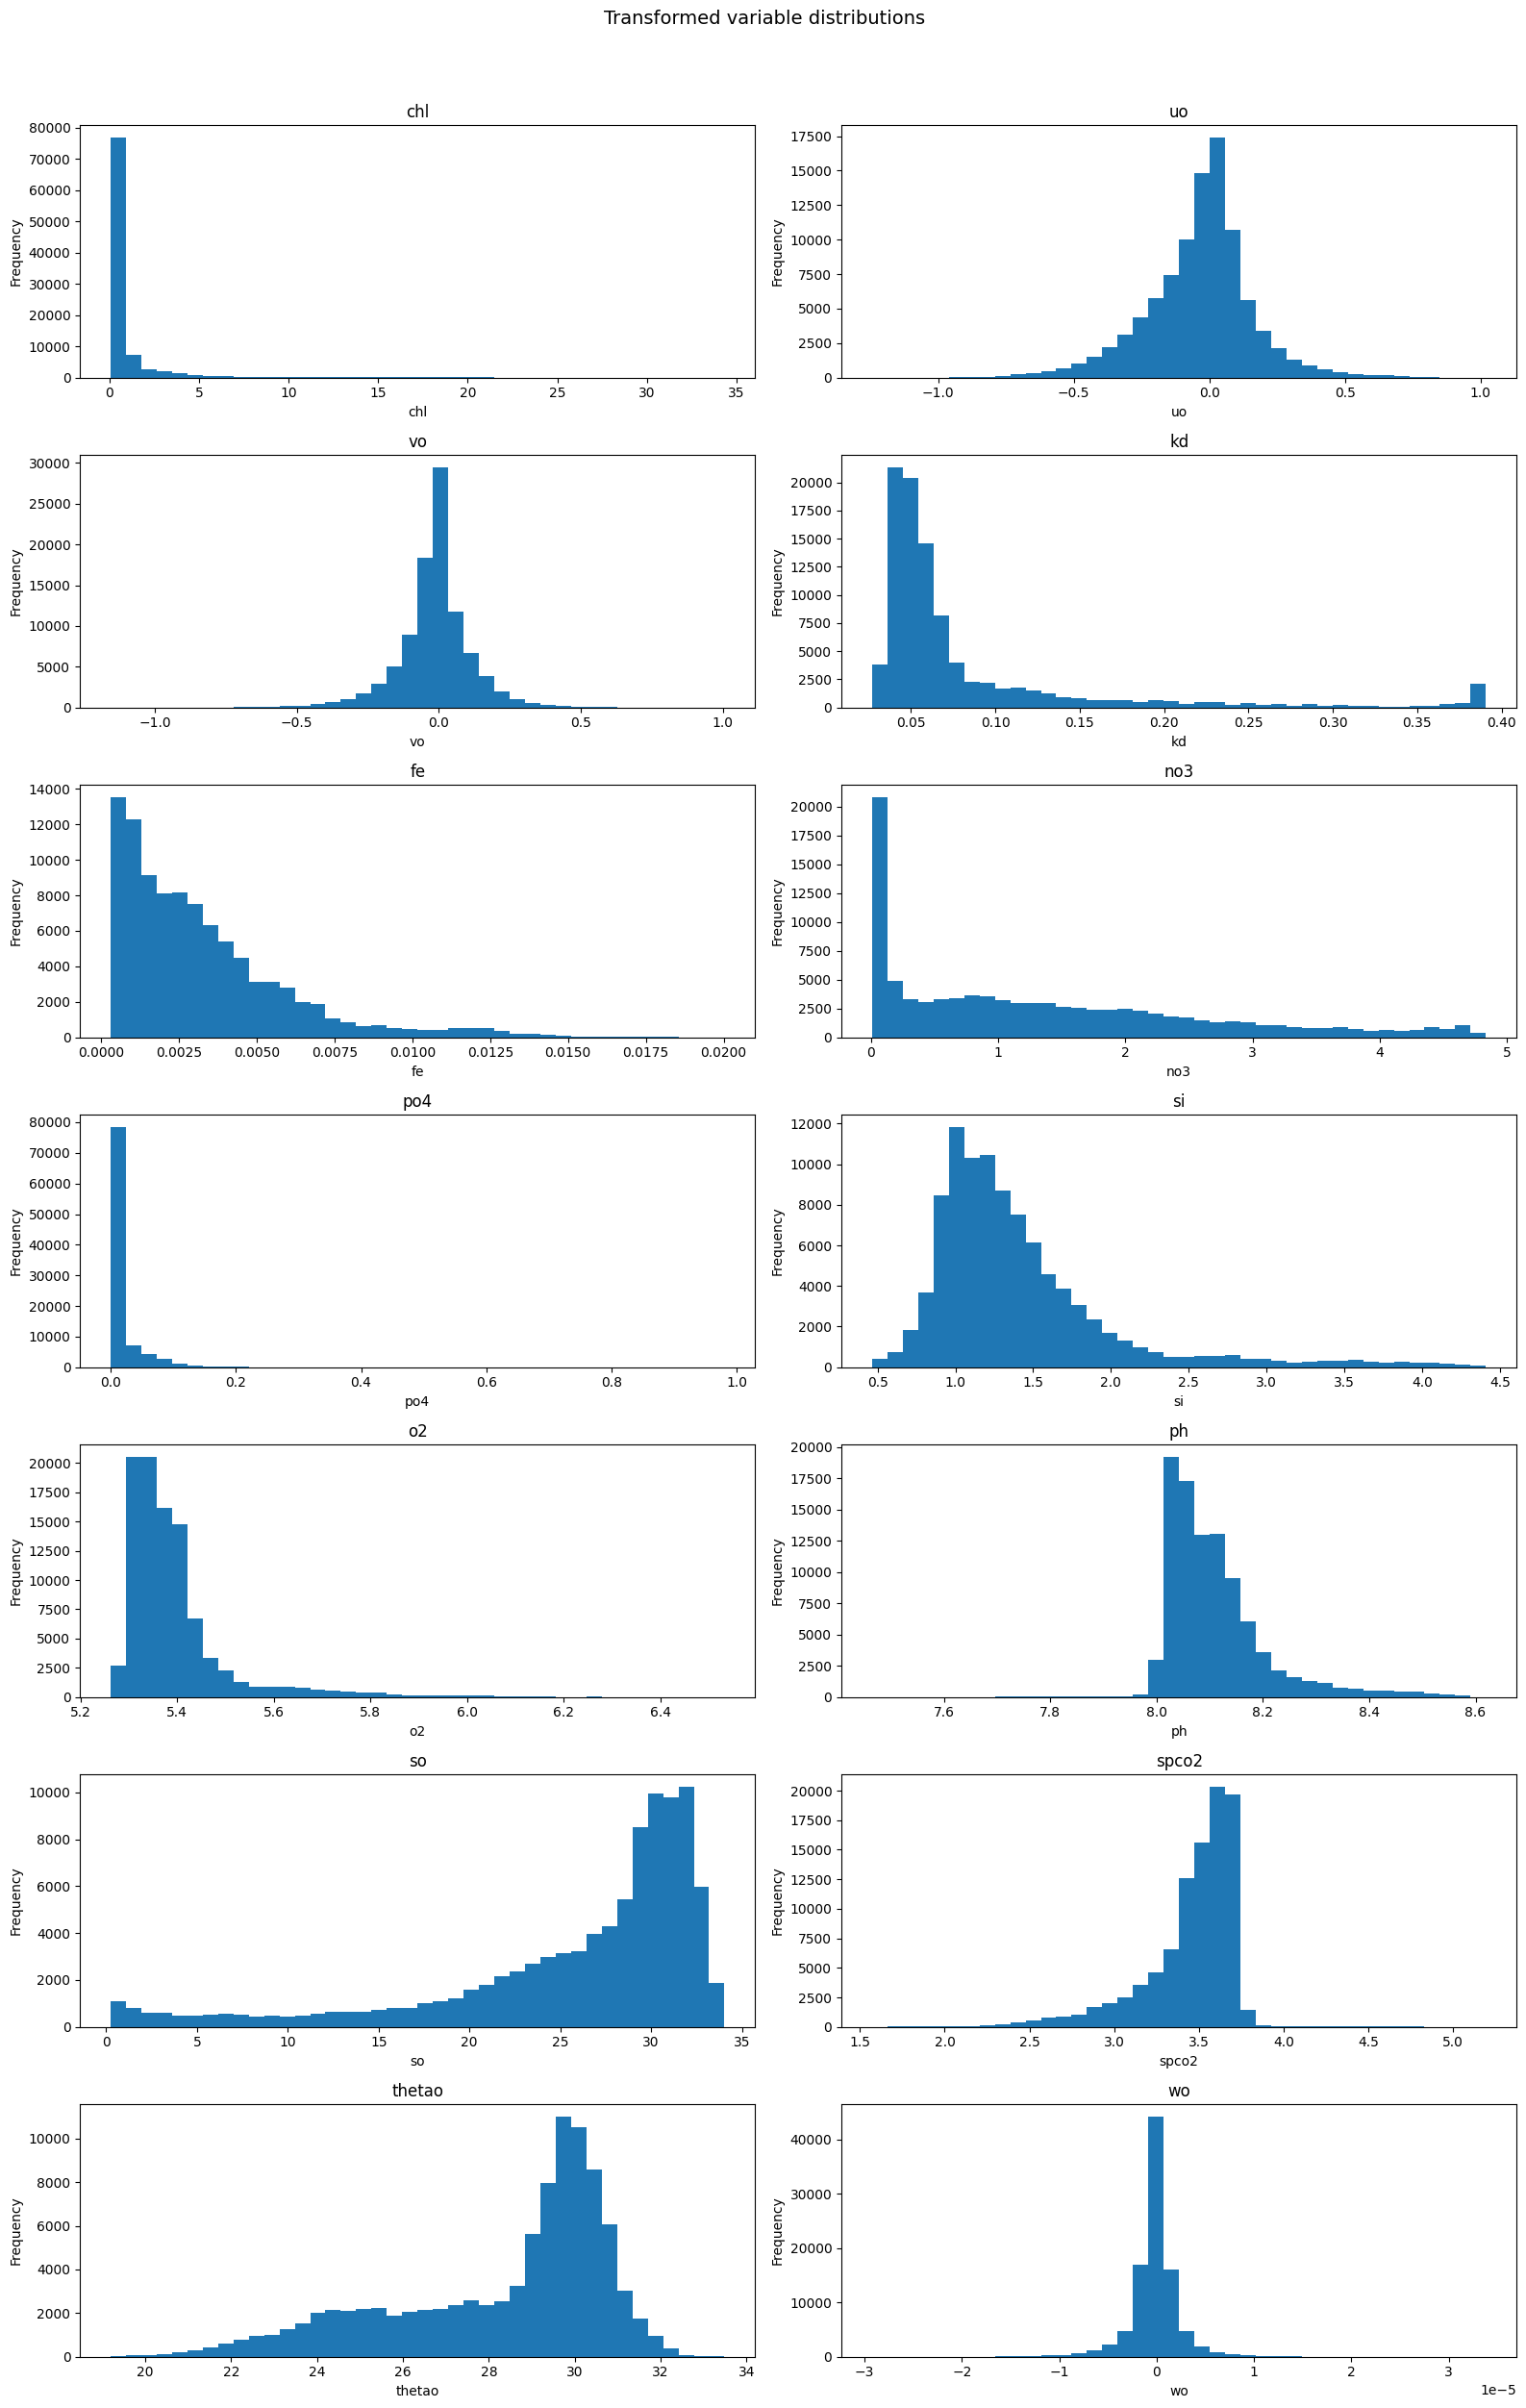

In [8]:
n = data_log1p_no_coords.shape[1]
cols_per_row = 2
rows = (n + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(16, rows * 3.5))
for i, col in enumerate(data_log1p_no_coords.columns):
    ax = plt.subplot(rows, cols_per_row, i + 1)
    # coerce to numeric for plotting safety
    vals = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").dropna()
    if vals.size == 0:
        ax.text(0.5, 0.5, f"No numeric data\nfor {col}", ha="center", va="center")
        ax.set_title(col)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ax.hist(vals, bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Transformed variable distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

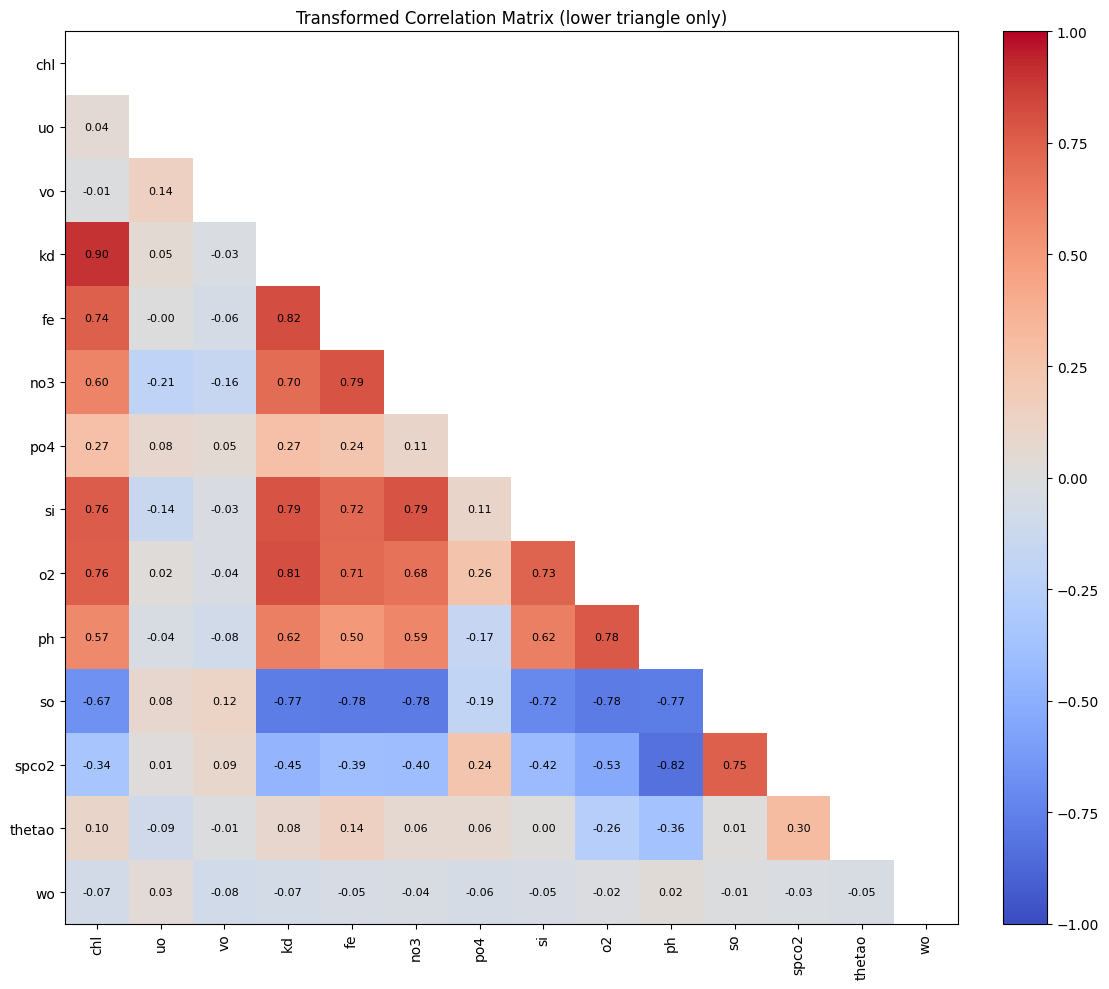

In [9]:
corr = data_log1p_no_coords.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

fig, ax = plt.subplots(figsize=(12, 10))
# Masked values are drawn as white
im = ax.imshow(corr.where(~mask), cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Show correlation coefficients in the lower triangle only
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i > j:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.title("Transformed Correlation Matrix (lower triangle only)")
plt.tight_layout()
plt.show()

In [10]:
data_log1p.to_csv("data_normalized.csv", index=False)

In [11]:
from sklearn.metrics import r2_score

target = "chl"
results = []
feature_cols = [col for col in data_log1p_no_coords.columns if col != target]

n_features = len(feature_cols)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

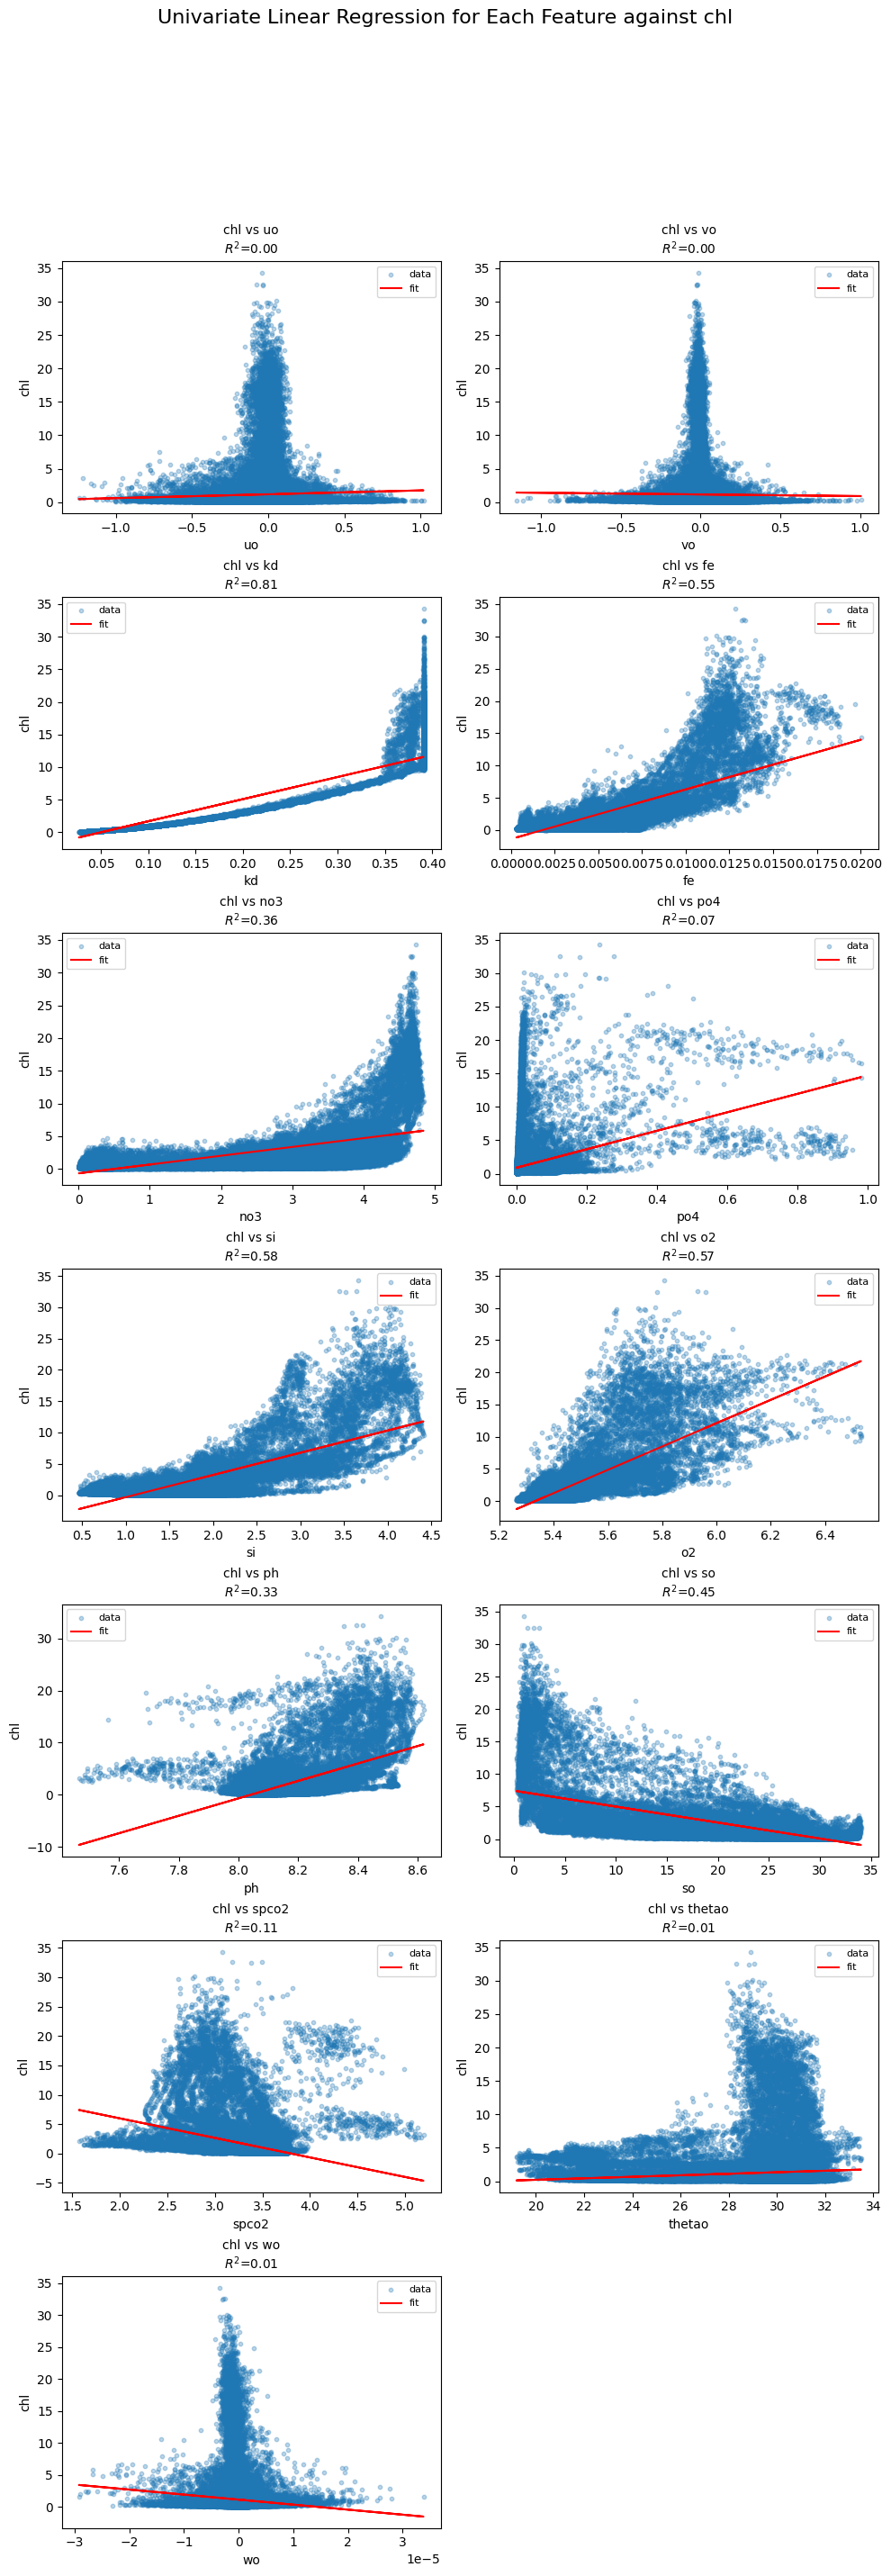

,feature,coef,intercept,r2
0,kd,33.938780,-1.700738,0.808536
1,si,3.547860,-3.878019,0.577859
2,o2,18.106262,-96.540944,0.573294
3,fe,767.865812,-1.370851,0.550972
4,so,-0.245157,7.450182,0.446546
5,no3,1.346474,-0.675724,0.359318
6,ph,16.724378,-134.485044,0.330036
7,spco2,-3.325427,12.640417,0.113468
8,po4,13.824883,0.897291,0.074797
9,thetao,0.113054,-2.053348,0.010404


In [12]:
from sklearn.linear_model import LinearRegression

results = []

# Perform regression, record results, and store data for plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    X = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").values.reshape(-1, 1)
    y = pd.to_numeric(data_log1p_no_coords[target], errors="coerce").values
    mask = (~pd.isna(X).flatten()) & (~pd.isna(y))
    X_clean = X[mask].reshape(-1, 1)
    y_clean = y[mask]
    if X_clean.shape[0] == 0:
        continue
    lr = LinearRegression()
    lr.fit(X_clean, y_clean)
    y_pred = lr.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    coef = lr.coef_[0]
    intercept = lr.intercept_
    results.append({
        "feature": col,
        "coef": coef,
        "intercept": intercept,
        "r2": r2
    })
    # Plot regression scatter with line
    ax = axes[idx]
    ax.scatter(X_clean, y_clean, alpha=0.3, label='data', s=10)
    ax.plot(X_clean, y_pred, color='red', label='fit')
    ax.set_title(f"{target} vs {col}\n$R^2$={r2:.2f}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.legend(fontsize=8)

# Hide any unused subplots
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Univariate Linear Regression for Each Feature against chl", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()

# Sort results by absolute value of R^2
results_sorted = sorted(results, key=lambda d: abs(d["r2"]), reverse=True)

# Tabulate results
df_results = pd.DataFrame(results_sorted)
df_results

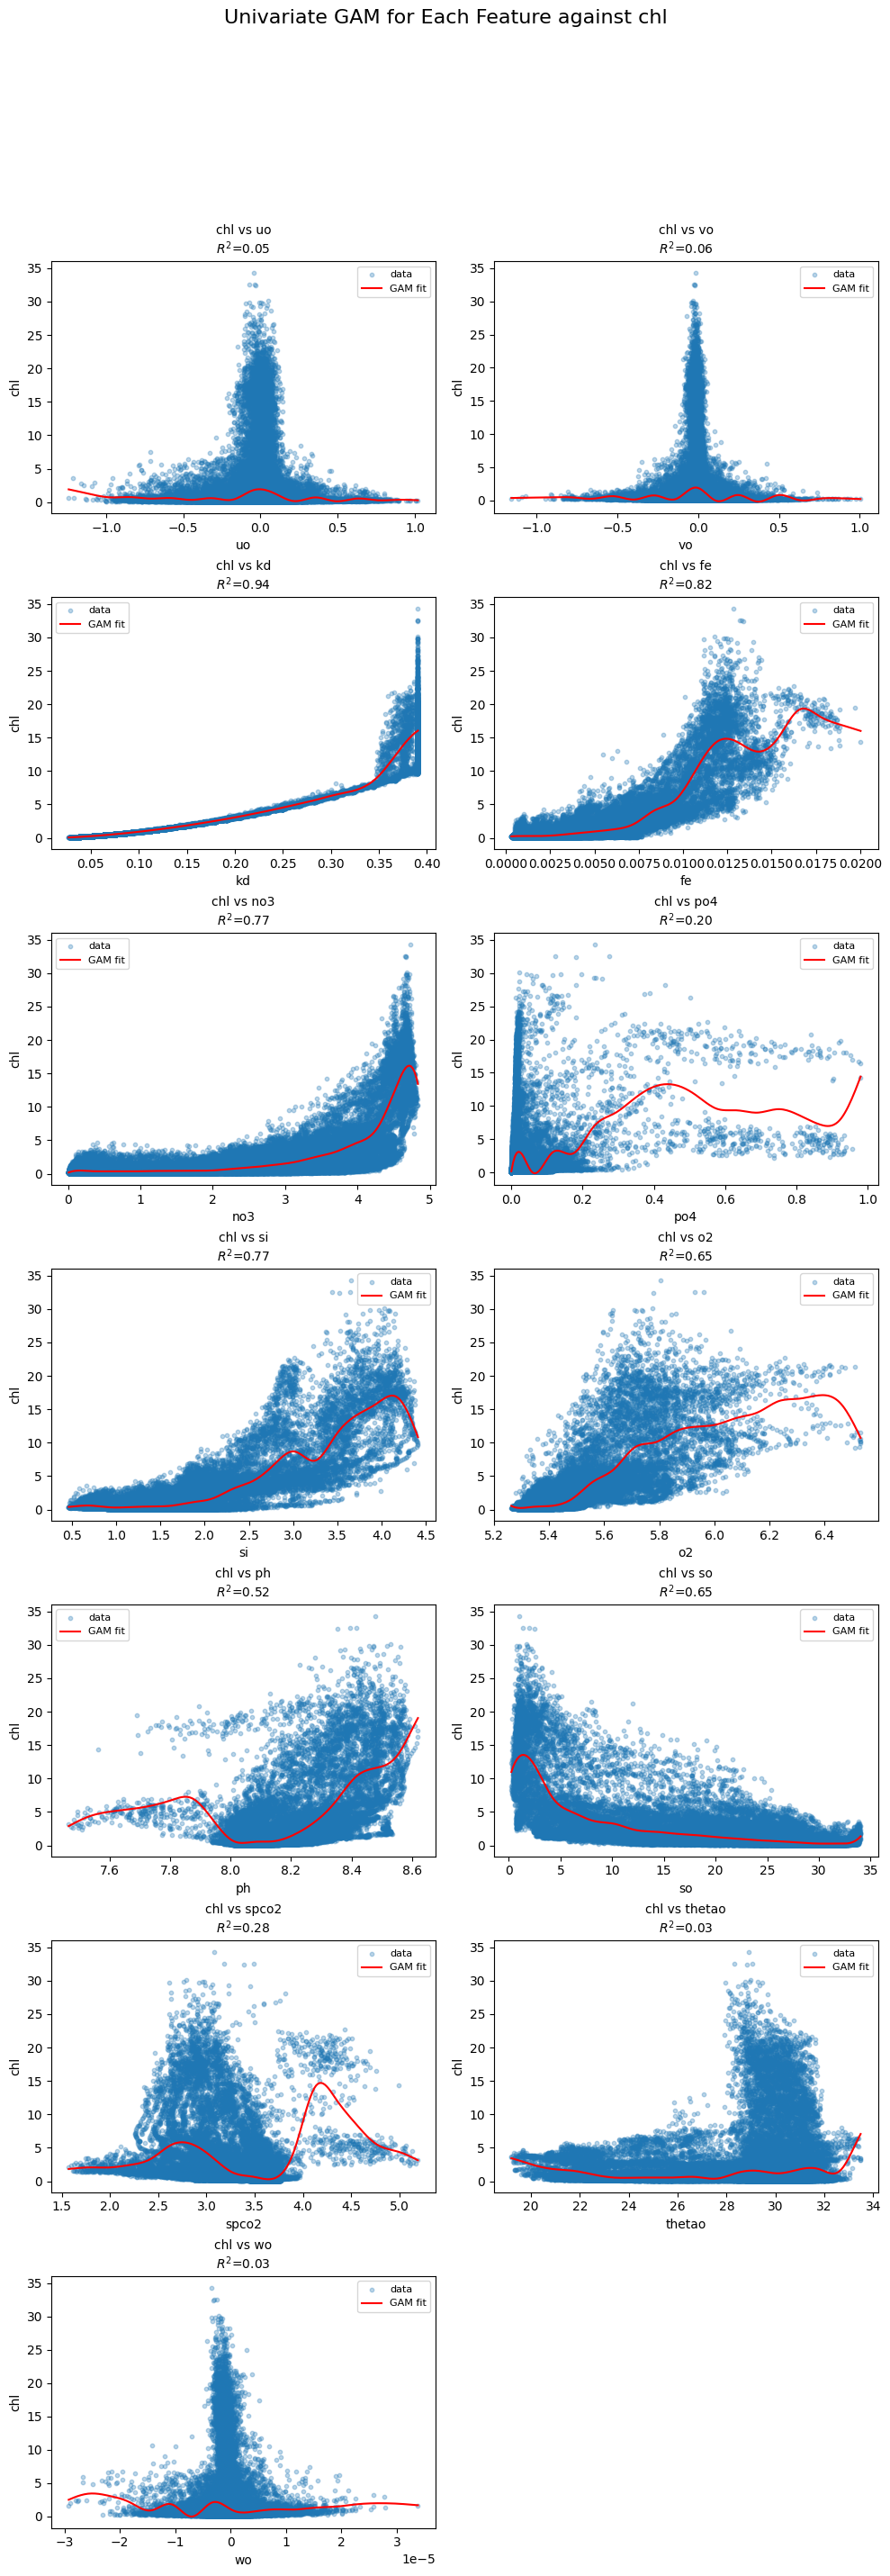

,feature,r2
0,kd,0.936625
1,fe,0.815331
2,no3,0.769613
3,si,0.766362
4,so,0.648293
5,o2,0.647132
6,ph,0.519128
7,spco2,0.276247
8,po4,0.204024
9,vo,0.061524


In [13]:
from pygam import LinearGAM, s

results = []

# Perform univariate GAM regression, record results, and store data for plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    X = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").values.reshape(-1, 1)
    y = pd.to_numeric(data_log1p_no_coords[target], errors="coerce").values
    mask = (~pd.isna(X).flatten()) & (~pd.isna(y))
    X_clean = X[mask].reshape(-1, 1)
    y_clean = y[mask]
    if X_clean.shape[0] == 0:
        continue
    gam = LinearGAM(s(0))
    gam.fit(X_clean, y_clean)
    y_pred = gam.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    # For GAM, there is no coef/intercept like in linear regression, but show importance as explained variance
    results.append({
        "feature": col,
        "r2": r2
    })
    # Plot regression scatter with smooth GAM line
    ax = axes[idx]
    # Plot scatter data
    ax.scatter(X_clean, y_clean, alpha=0.3, label='data', s=10)
    # Plot smooth GAM prediction curve
    XX = np.linspace(X_clean.min(), X_clean.max(), 200).reshape(-1, 1)
    ax.plot(XX, gam.predict(XX), color='red', label='GAM fit')
    ax.set_title(f"{target} vs {col}\n$R^2$={r2:.2f}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.legend(fontsize=8)

# Hide any unused subplots
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Univariate GAM for Each Feature against chl", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()

# Sort results by absolute value of R^2
results_sorted = sorted(results, key=lambda d: abs(d["r2"]), reverse=True)

# Tabulate results
df_results = pd.DataFrame(results_sorted)
df_results